<h1>Classification of dermatological Fungi Dataset</h1>

<h3>Importing Required Libraries</h3>

In [1]:
import numpy as np  # numpy for array manipulation
import tensorflow as tf 

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split

from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torchvision.models import resnet101, ResNet101_Weights # Loading Pre-trained CNN Model Resnet

from sklearn.metrics import confusion_matrix , accuracy_score
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2024-12-09 10:43:57.813893: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-09 10:44:14.207283: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-09 10:44:29.090332: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/cc/vfaculty/varunj.vfaculty/.conda/envs/defungi_project_final/lib:/usr/local/cuda-11.8/lib64{LD_LIBRARY_PATH:+:}:/home/soft/centOS/lib/gnu/tcl/8.4.20/lib
2024-12-09 10:44:29.091244: W tensorflow/stream_exec

<h4>Loading the Images Dataset</h4>

In [ ]:
!wget --content-disposition --content-disposition "https://archive.ics.uci.edu/static/public/773/defungi.zip"
!unzip defungi.zip -d ./data
!pip install split-folders
import splitfolders
splitfolders.ratio("./data", output="./partitions",seed=SEED, ratio=(0.75, 0.15, 0.1), group_prefix=None, move=False)

--2024-12-02 18:16:09--  https://archive.ics.uci.edu/static/public/773/defungi.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘defungi.zip.1’

defungi.zip.1           [          <=>       ] 149.10M  28.3MB/s    in 5.2s    

2024-12-02 18:16:14 (28.8 MB/s) - ‘defungi.zip.1’ saved [156341364]

Archive:  defungi.zip
replace ./data/H1/H1_100a_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Requirement already satisfied: split-folders in /usr/local/lib/python3.10/dist-packages (0.5.1)


Copying files: 9114 files [00:02, 4063.42 files/s]


In [2]:
dataset = ImageFolder("./partitions/train") # Using the path to the training data

# Splitting the dataset into training and validation subsets:
# - The dataset is split into 70% training data and 30% validation data.
# - `random_split` is used to create two non-overlapping subsets.
# - The size of the training data is calculated as 70% of the dataset length.
# - The remaining data forms the validation set.

train_data, val_data = random_split(dataset, [int(len(dataset)*0.7), int(len(dataset)-(int(len(dataset)*0.7)))])

# Display the sizes of the training and validation datasets
len(train_data), len(val_data)

(4783, 2051)

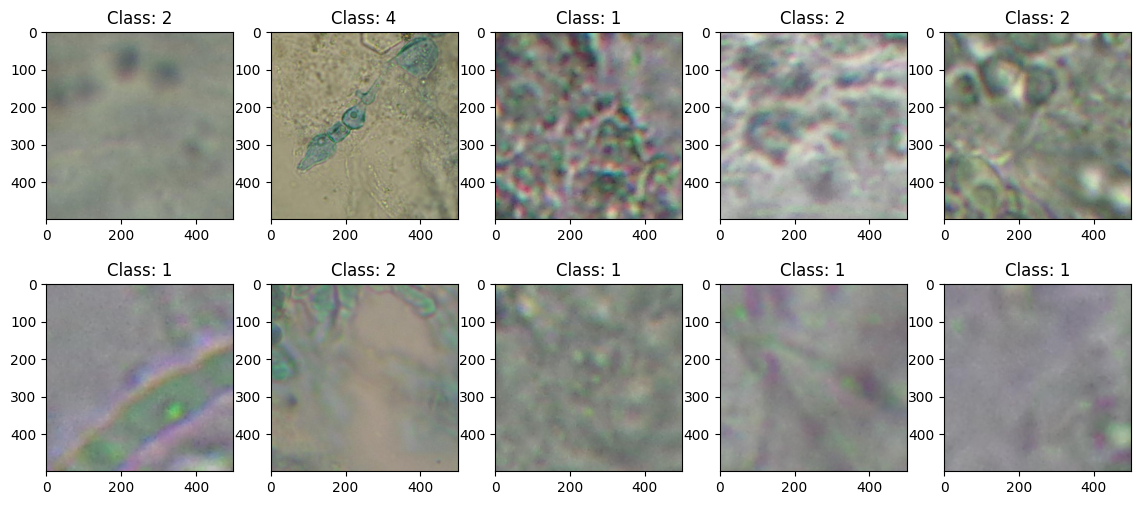

In [3]:
fig, ax = plt.subplots(2, 5, figsize=(14, 6))
for i in range(10):
    ax[i//5, i%5].imshow(train_data[i][0])
    ax[i//5, i%5].set_title(f'Class: {train_data[i][1] + 1}')
    ax[i//5, i%5].axis('on')

plt.show()

<h5>Division of Fungi into classes</h5>

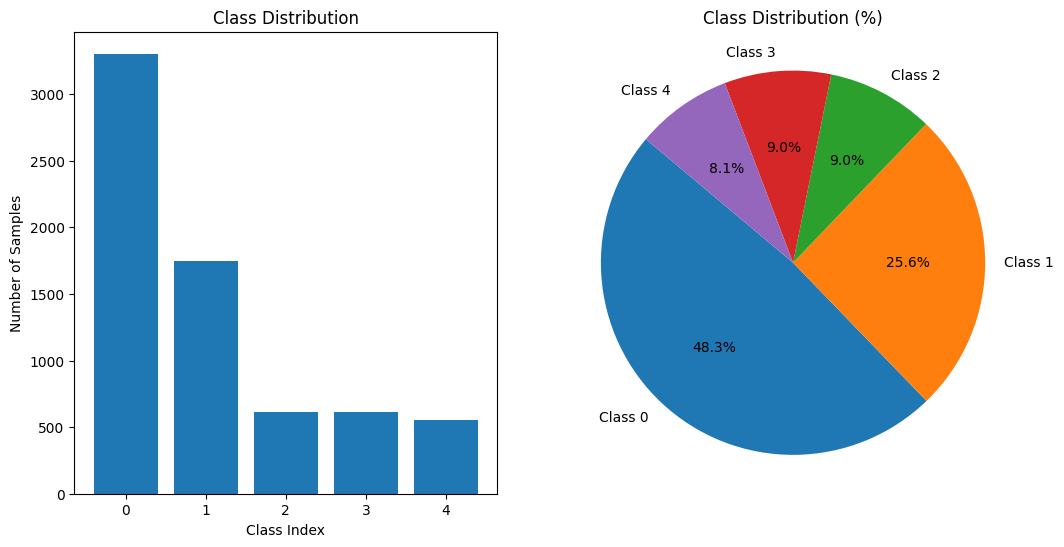

In [4]:
class_indices = torch.tensor(dataset.targets)  #converts the class labels from the dataset into a PyTorch tensor.
class_counts = torch.bincount(class_indices)
class_counts_dict = {class_idx: count.item() for class_idx, count in enumerate(class_counts) if count > 0}

total_samples = len(dataset)
class_percentages = {class_idx: count / total_samples * 100 for class_idx, count in class_counts_dict.items()}
labels = [f'Class {class_idx}' for class_idx in class_percentages.keys()]
sizes = list(class_percentages.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.bar(class_counts_dict.keys(), class_counts_dict.values())
ax1.set_xlabel('Class Index')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Class Distribution')
ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
ax2.axis('equal')
ax2.set_title('Class Distribution (%)')

plt.show()

<h2> Applying Transformation on Images </h2>

In [5]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


train_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5),
    v2.PILToTensor(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.PILToTensor(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = MyDataset(train_data, train_transforms)
val_dataset = MyDataset(val_data, data_transforms)

In [6]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

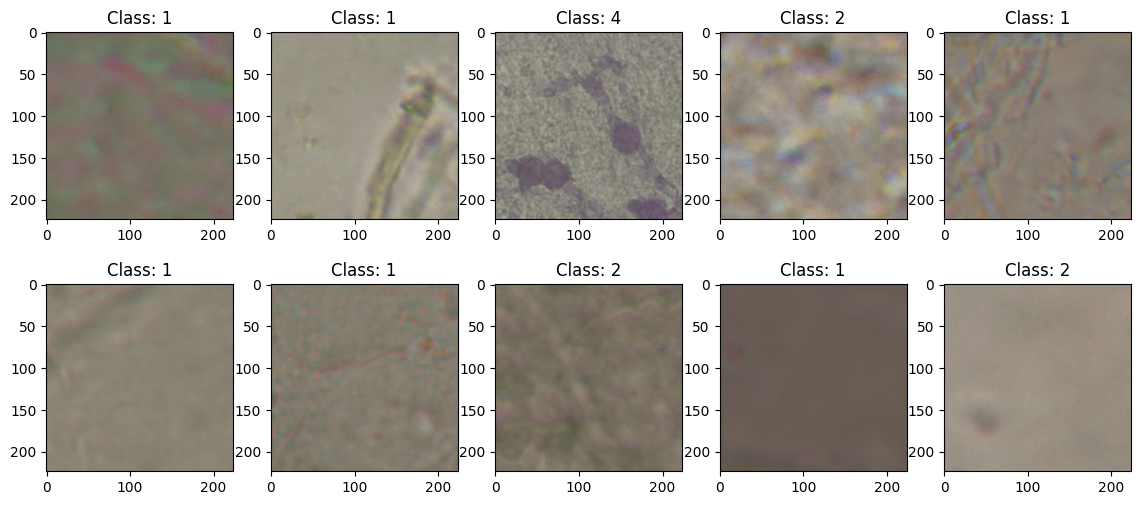

In [7]:
unnormalize = v2.Compose([
    v2.Normalize((0.0, 0.0, 0.0), (1/0.229, 1/0.224, 1/0.225)),
    v2.Normalize((-0.485, -0.456, -0.406), (1.0, 1.0, 1.0)),
])

it = iter(train_loader)
x, y = next(it)

fig, ax = plt.subplots(2, 5, figsize=(14, 6))
for i in range(10):
    ax[i//5, i%5].imshow(unnormalize(x[i]).permute(1, 2, 0))
    ax[i//5, i%5].set_title(f'Class: {y[i].item() + 1}')
    ax[i//5, i%5].axis('on')

plt.show()

MODEL ARCHITECTURE

In [8]:
torch.manual_seed(9)
torch.cuda.manual_seed(9)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
class MyResNet101(nn.Module):
    def __init__(self, num_classes):
        super(MyResNet101, self).__init__()
        self.resnet = resnet101(weights=ResNet101_Weights.DEFAULT)
        self.resnet.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        return self.resnet(x)

In [10]:
model = MyResNet101(num_classes=5).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

model

MyResNet101(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

Training and Evaluation

In [11]:
import time

In [12]:
start_time = time.time()
epochs = 25

train_loss_list = []
val_loss_list = []
val_acc_list = []
for epoch in range(epochs):
    train_loss = 0.0
    for batch, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        model.train()
        y_pred = model(images)

        loss = loss_fn(y_pred, labels)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 10 == 0:
            print(f"Analyzed {batch * len(images)}/{len(train_loader.dataset)} samples")

    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            y_val_pred = model(images)
            val_loss += loss_fn(y_val_pred, labels).item()
            val_acc += accuracy_score(labels.cpu(), y_val_pred.argmax(dim=1).cpu())
        val_loss /= len(val_loader)
        val_loss_list.append(val_loss)
        val_acc /= len(val_loader)
        val_acc_list.append(val_acc)

    train_loss /= len(train_loader)
    train_loss_list.append(train_loss)
    print(f"{epoch:02d}: Train loss: {train_loss:.5f} | Validation loss: {val_loss:.5f}, Validation acc: {(val_acc * 100):.2f}%")

print("--- %s seconds ---" % (time.time() - start_time))

Analyzed 0/4783 samples
Analyzed 640/4783 samples
Analyzed 1280/4783 samples
Analyzed 1920/4783 samples
Analyzed 2560/4783 samples
Analyzed 3200/4783 samples
Analyzed 3840/4783 samples
Analyzed 4480/4783 samples
00: Train loss: 1.06575 | Validation loss: 0.84175, Validation acc: 66.37%
Analyzed 0/4783 samples
Analyzed 640/4783 samples
Analyzed 1280/4783 samples
Analyzed 1920/4783 samples
Analyzed 2560/4783 samples
Analyzed 3200/4783 samples
Analyzed 3840/4783 samples
Analyzed 4480/4783 samples
01: Train loss: 0.79247 | Validation loss: 0.65939, Validation acc: 74.76%
Analyzed 0/4783 samples
Analyzed 640/4783 samples
Analyzed 1280/4783 samples
Analyzed 1920/4783 samples
Analyzed 2560/4783 samples
Analyzed 3200/4783 samples
Analyzed 3840/4783 samples
Analyzed 4480/4783 samples
02: Train loss: 0.64620 | Validation loss: 0.61750, Validation acc: 74.40%
Analyzed 0/4783 samples
Analyzed 640/4783 samples
Analyzed 1280/4783 samples
Analyzed 1920/4783 samples
Analyzed 2560/4783 samples
Analyzed

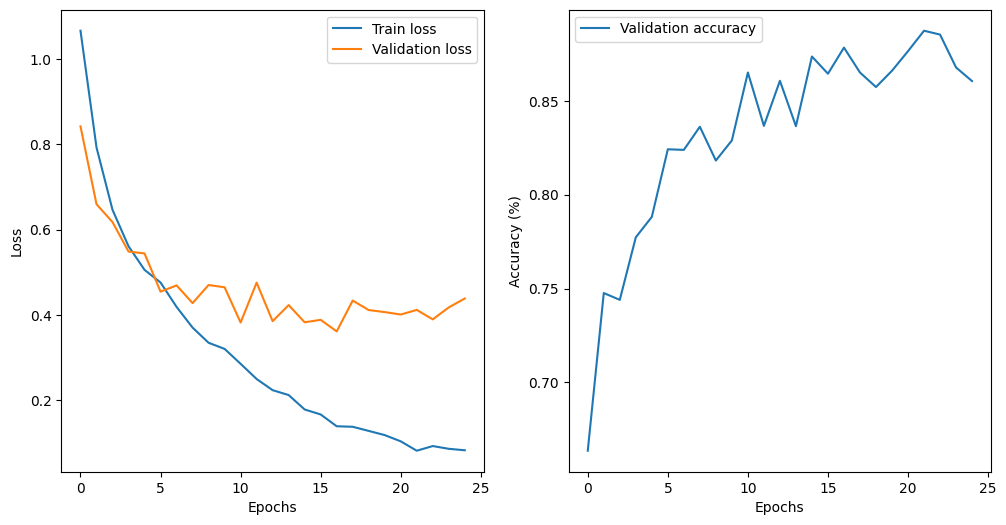

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(train_loss_list, label='Train loss')
ax1.plot(val_loss_list, label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(val_acc_list, label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.show()

In [14]:
val_acc = 0.0
preds_all = []
labels_all = []
model.eval()
with torch.inference_mode():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        y_val_pred = model(images)
        val_acc += accuracy_score(labels.cpu(), y_val_pred.argmax(dim=1).cpu())

        labels_all.extend(labels.cpu())
        preds_all.extend(y_val_pred.argmax(dim=1).cpu())
    val_acc /= len(val_loader)

preds_all = np.array(preds_all)
labels_all = np.array(labels_all)

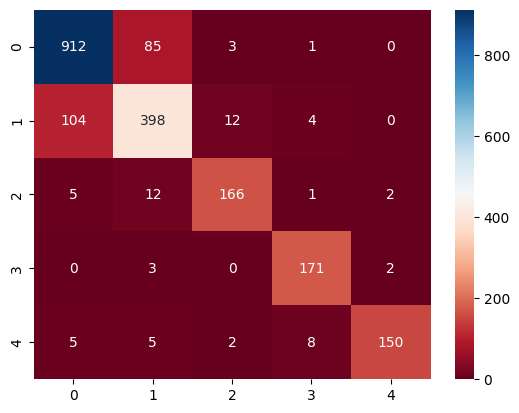

In [15]:
cmatrix = confusion_matrix(labels_all, preds_all)
classes = [0, 1, 2, 3, 4]
sns.heatmap(cmatrix, annot=True, fmt=".0f", cmap='RdBu', xticklabels=classes, yticklabels=classes)
plt.show()

In [16]:
print(classification_report(labels_all, preds_all))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1001
           1       0.79      0.77      0.78       518
           2       0.91      0.89      0.90       186
           3       0.92      0.97      0.95       176
           4       0.97      0.88      0.93       170

    accuracy                           0.88      2051
   macro avg       0.90      0.89      0.89      2051
weighted avg       0.88      0.88      0.88      2051



Model_A

In [17]:
from sklearn.model_selection import train_test_split
from PIL import Image
from keras.models import Sequential, Model
from keras.utils import np_utils, plot_model
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, DenseNet121, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import os

In [18]:
labels = {'H1': 0,
         'H2': 1,
         'H3': 2,
         'H5': 3,
         'H6': 4}

X=[]
Y=[]

for dir, label in labels.items():
    path = os.path.join("/home/cc/vfaculty/varunj.vfaculty/varun_test/defungi_AI_Project/data", dir)
    img_files = os.listdir(path)
    for file in img_files:
        #X.append(mpimg.imread(path+"\\"+file))
        # With 500x500x3 image sizes, I was getting runtimes around 15 mins/epoch for batch sizes of 20.  
        # Need to rescale images and maybe grayscale them.
        X.append(Image.open(path+"/"+file).resize((200, 200)))
        Y.append(label)
        #print("file "+path+"\\"+file+" appended")

In [19]:
X = np.array(X)
# meant to keep it lower case
y = np.array(Y)

/var/tmp/pbs.217781.pbshpc/ipykernel_51136/902150222.py:1: FutureWarning: The input object of type 'Image' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Image', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  X = np.array(X)
/var/tmp/pbs.217781.pbshpc/ipykernel_51136/902150222.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.array(X)


In [20]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Initialize lists
X = []
Y = []

# Assume `labels` is a dictionary mapping folder names to labels
for dir, label in labels.items():
    path = os.path.join("/home/cc/vfaculty/varunj.vfaculty/varun_test/defungi_AI_Project/data", dir)
    if not os.path.exists(path):
        print(f"Path {path} does not exist.")
        continue
    
    img_files = os.listdir(path)
    for file in img_files:
        file_path = os.path.join(path, file)
        try:
            # Load, resize, and normalize the image
            img = Image.open(file_path).resize((200, 200)).convert("RGB")
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]
            X.append(img_array)
            Y.append(label)
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")

# Convert lists to NumPy arrays
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.int32)

# Print debug information
print(f"Shape of X: {X.shape}")  # Should be (num_samples, 200, 200, 3)
print(f"Shape of Y: {Y.shape}")  # Should be (num_samples,)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=13013)

# Define the CNN model
model_A = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(200, 200, 3)),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])

model_A.summary()

# Compile the model
model_A.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
model_A_fit = model_A.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=25
)


Shape of X: (9114, 200, 200, 3)
Shape of Y: (9114,)


2024-12-09 11:34:03.040930: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-09 11:34:10.436469: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 68620 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:ca:00.0, compute capability: 8.0
2024-12-09 11:34:10.514341: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78324 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:87:00.0, compute capability: 8.0


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 200, 200, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 100, 100, 32)     0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 320000)            0         
                                                                 
 dense (Dense)               (None, 128)               40960128  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 645       
                                                        

2024-12-09 11:34:40.186631: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8100
2024-12-09 11:35:17.602211: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


228/228 [==============================] - 78s 15ms/step - loss: 2.5582 - accuracy: 0.5156 - val_loss: 1.0682 - val_accuracy: 0.5771
Epoch 2/25
228/228 [==============================] - 3s 11ms/step - loss: 1.1165 - accuracy: 0.5575 - val_loss: 1.0184 - val_accuracy: 0.5930
Epoch 3/25
228/228 [==============================] - 3s 11ms/step - loss: 1.0361 - accuracy: 0.5966 - val_loss: 0.9981 - val_accuracy: 0.5968
Epoch 4/25
228/228 [==============================] - 3s 11ms/step - loss: 0.9946 - accuracy: 0.6064 - val_loss: 0.9358 - val_accuracy: 0.6231
Epoch 5/25
228/228 [==============================] - 3s 11ms/step - loss: 0.9534 - accuracy: 0.6309 - val_loss: 0.9629 - val_accuracy: 0.6050
Epoch 6/25
228/228 [==============================] - 2s 11ms/step - loss: 0.9363 - accuracy: 0.6330 - val_loss: 0.9497 - val_accuracy: 0.6072
Epoch 7/25
228/228 [==============================] - 3s 11ms/step - loss: 0.9112 - accuracy: 0.6470 - val_loss: 0.9709 - val_accuracy: 0.6116
Epoch 8/2

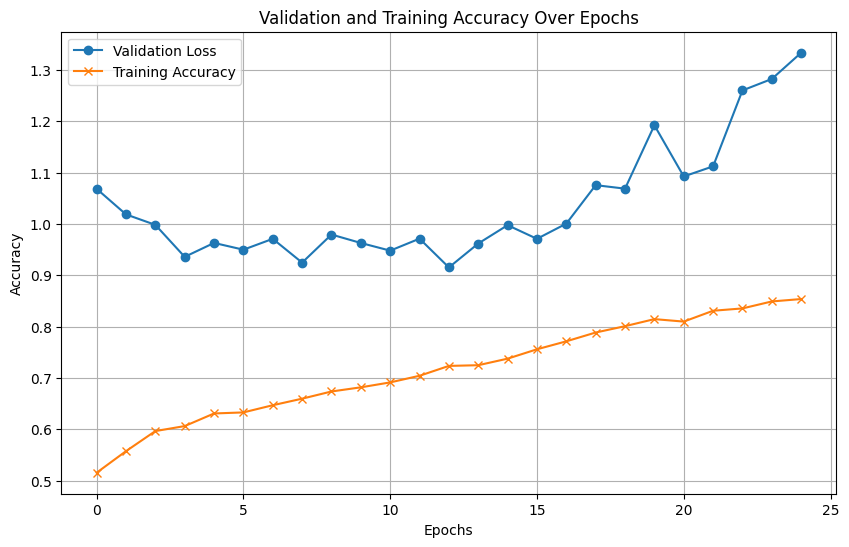

In [34]:
# Plot Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(model_A_fit.history['val_loss'], label='Validation Loss', marker='o')
plt.plot(model_A_fit.history['accuracy'], label='Training Accuracy', marker='x')
plt.title('Validation and Training Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

Heat-Map

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

57/57 [==============================] - 0s 4ms/step


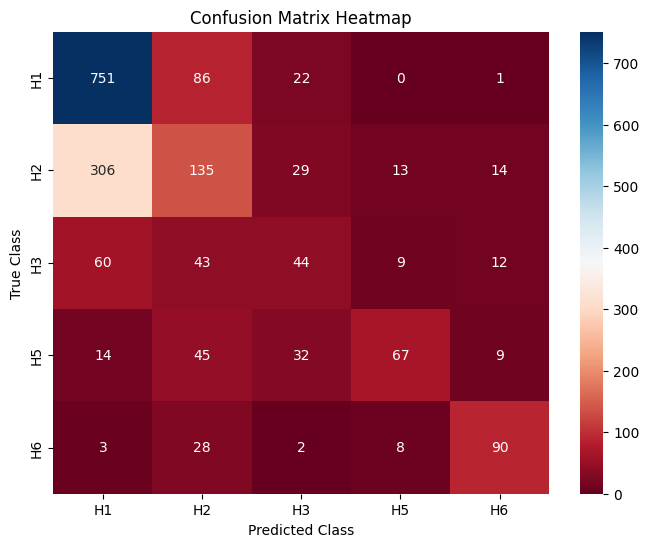

In [24]:
y_pred = model_A.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Generate Confusion Matrix
conf_matrix_A = confusion_matrix(y_test, y_pred_classes)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_A, annot=True, fmt='d', cmap='RdBu', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

Confusion Matrices

In [25]:
# Print Classification Report
print(classification_report(y_test, y_pred_classes, target_names=labels))

              precision    recall  f1-score   support

          H1       0.66      0.87      0.75       860
          H2       0.40      0.27      0.32       497
          H3       0.34      0.26      0.30       168
          H5       0.69      0.40      0.51       167
          H6       0.71      0.69      0.70       131

    accuracy                           0.60      1823
   macro avg       0.56      0.50      0.52      1823
weighted avg       0.57      0.60      0.57      1823



model_B

In [26]:
model_B = Sequential([
    Conv2D(256,(3,3),padding='same',activation='relu',input_shape=(200,200,3)),
    MaxPooling2D(),
    Conv2D(256,(3,3),padding='same',activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(5,activation='softmax')
])

model_B.summary()

model_B.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics='accuracy'
)

model_B_fit = model_B.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=32, epochs=25)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 200, 200, 256)     7168      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 100, 100, 256)    0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 100, 100, 256)     590080    
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 50, 50, 256)      0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 640000)            0         
                                                                 
 dense_2 (Dense)             (None, 128)              

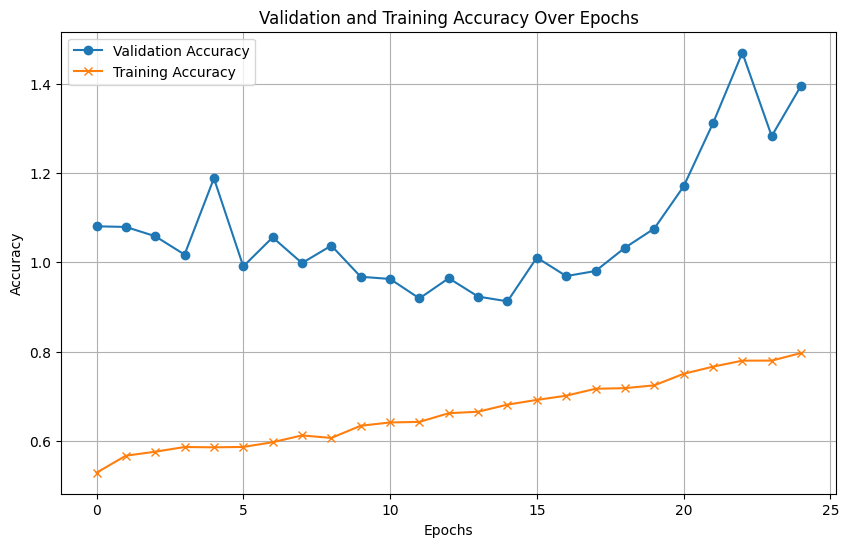

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(model_B_fit.history['val_loss'], label='Validation Accuracy', marker='o')
plt.plot(model_B_fit.history['accuracy'], label='Training Accuracy', marker='x')
plt.title('Validation and Training Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

57/57 [==============================] - 2s 27ms/step


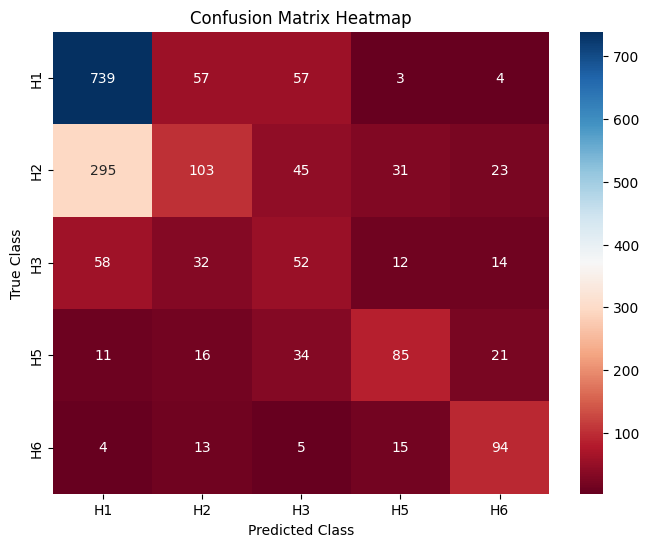

In [38]:
y_pred_B = model_B.predict(X_test)
y_pred_classes_B = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Generate Confusion Matrix
conf_matrix_B = confusion_matrix(y_test, y_pred_classes_B)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_B, annot=True, fmt='d', cmap='RdBu', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [39]:
print(classification_report(y_test, y_pred_classes_B, target_names=labels))

              precision    recall  f1-score   support

          H1       0.67      0.86      0.75       860
          H2       0.47      0.21      0.29       497
          H3       0.27      0.31      0.29       168
          H5       0.58      0.51      0.54       167
          H6       0.60      0.72      0.66       131

    accuracy                           0.59      1823
   macro avg       0.52      0.52      0.50      1823
weighted avg       0.56      0.59      0.56      1823

